In [26]:
# ============================================================
# DATA PREPROCESSING PIPELINE
# Snow Cover Analysis | Shemonaikha Region (50.62°N, 81.92°E)
# Period: 2014-2023
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10

In [27]:
# ============================================================
# CONFIGURATION
# ============================================================

# Study area coordinates
LAT, LON = 50.6216435, 81.918251
ELEVATION_M = 302.0
SLOPE_DEG = 1.7
ASPECT_DEG = 302.4

# File paths
DATA_DIR = Path('data')
ERA5_RAW = DATA_DIR / 'era5_2014_2023_daily_region2.csv'
MODIS_LST = DATA_DIR / 'MODIS_LST_2014_2023_Region2.csv'
MODIS_SNOW = DATA_DIR / 'MODIS_Snow_Albedo_2014_2023_Region2.csv'
GROUND_OBS = DATA_DIR / 'shemonaikha.csv'

PROCESSED_DIR = Path('processed')
PROCESSED_DIR.mkdir(exist_ok=True)

# Summer months to exclude
SUMMER_MONTHS = [6, 7, 8, 9]

### 1. ERA5-Land Data Cleaning

In [28]:
# ============================================================
# 1. ERA5-LAND DATA CLEANING
# ============================================================
print("=" * 60)
print("1. PROCESSING ERA5-LAND DATA")
print("=" * 60)

# Load raw data
era5 = pd.read_csv(ERA5_RAW)
era5['date'] = pd.to_datetime(era5['date'])

# Drop system columns
cols_to_drop = ['system:index', '.geo']
era5 = era5.drop(columns=[c for c in cols_to_drop if c in era5.columns])

print(f"Loaded: {len(era5)} days")
print(f"Period: {era5['date'].min().date()} to {era5['date'].max().date()}")

# Unit conversions
era5['temperature_2m_C'] = era5['temperature_2m'] - 273.15        # K → °C
era5['precipitation_mm'] = era5['total_precipitation_sum'] * 1000  # m → mm
era5['swe_mm'] = era5['snow_depth_water_equivalent'] * 1000        # m → mm
era5['snow_depth_cm'] = era5['snow_depth'] * 100                  # m → cm
era5['solar_radiation_MJ'] = era5['surface_solar_radiation_downwards_sum'] / 1_000_000
era5['thermal_radiation_MJ'] = era5['surface_thermal_radiation_downwards_sum'] / 1_000_000

# Fix numerical noise (negative values close to zero)
for col in ['precipitation_mm', 'swe_mm', 'snow_depth_cm']:
    mask = (era5[col] < 0) & (era5[col] > -0.1)
    era5.loc[mask, col] = 0

# Rename ERA5 snow_cover to avoid column name conflict with MODIS later
if 'snow_cover' in era5.columns:
    era5 = era5.rename(columns={'snow_cover': 'snow_cover_ERA5'})

# Add temporal features
era5['year'] = era5['date'].dt.year
era5['month'] = era5['date'].dt.month
era5['day'] = era5['date'].dt.day
era5['doy'] = era5['date'].dt.dayofyear

# Season classification
def classify_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

era5['season'] = era5['month'].apply(classify_season)

print(f"Cleaned: {len(era5)} days, {len(era5.columns)} variables")
print(f"Temperature range: {era5['temperature_2m_C'].min():.1f} to {era5['temperature_2m_C'].max():.1f}°C")
print(f"Mean SWE: {era5['swe_mm'].mean():.1f} mm")

1. PROCESSING ERA5-LAND DATA
Loaded: 3651 days
Period: 2014-01-01 to 2023-12-30
Cleaned: 3651 days, 25 variables
Temperature range: -35.9 to 31.1°C
Mean SWE: 48.0 mm


### 2. MODIS Data Integration

In [29]:
# ============================================================
# 2. MODIS DATA INTEGRATION
# ============================================================
print("\n" + "=" * 60)
print("2. INTEGRATING MODIS DATA")
print("=" * 60)

# 2.1 Load MODIS LST
modis_lst = pd.read_csv(MODIS_LST)
modis_lst['date'] = pd.to_datetime(modis_lst['date'])
print(f"MODIS LST: {len(modis_lst)} days")

# 2.2 Load MODIS Snow & Albedo
modis_snow = pd.read_csv(MODIS_SNOW)
modis_snow['date'] = pd.to_datetime(modis_snow['date'])

# Normalize MODIS albedo if needed (0-100 → 0-1)
if 'albedo' in modis_snow.columns:
    if modis_snow['albedo'].max() > 1:
        modis_snow['albedo_MODIS'] = modis_snow['albedo'] / 100
    else:
        modis_snow['albedo_MODIS'] = modis_snow['albedo']
else:
    raise KeyError("Column 'albedo' not found in MODIS snow file")

print(f"MODIS Snow: {len(modis_snow)} days")

# 2.3 Merge ERA5 with MODIS LST
merged = era5.merge(
    modis_lst[['date', 'LST_Day_C', 'LST_Night_C']],
    on='date', how='inner'
)

# 2.4 Merge with MODIS Snow (snow_cover column now won't conflict)
merged = merged.merge(
    modis_snow[['date', 'snow_cover', 'albedo_MODIS']],
    on='date', how='left'
)

# Now 'snow_cover' in merged is from MODIS → rename for clarity
merged = merged.rename(columns={'snow_cover': 'snow_cover_MODIS'})

# Temperature differences (MODIS LST minus ERA5 air temperature)
merged['temp_diff_day'] = merged['LST_Day_C'] - merged['temperature_2m_C']
merged['temp_diff_night'] = merged['LST_Night_C'] - merged['temperature_2m_C']

print(f"\nMerged dataset: {len(merged)} days")
print(f"MODIS snow cover available: {merged['snow_cover_MODIS'].notna().sum()} days")
print(f"MODIS albedo available: {merged['albedo_MODIS'].notna().sum()} days")
print(f"LST day available: {merged['LST_Day_C'].notna().sum()} days")
print(f"LST night available: {merged['LST_Night_C'].notna().sum()} days")


2. INTEGRATING MODIS DATA
MODIS LST: 3630 days
MODIS Snow: 3630 days

Merged dataset: 3630 days
MODIS snow cover available: 1281 days
MODIS albedo available: 146 days
LST day available: 1557 days
LST night available: 706 days


### 3. SRTM Topography Addition

In [30]:
# ============================================================
# 3. SRTM TOPOGRAPHY ADDITION
# ============================================================
print("\n" + "=" * 60)
print("3. ADDING SRTM DATA")
print("=" * 60)

# Add constant SRTM values for the study point
merged['elevation_m'] = ELEVATION_M
merged['slope_deg'] = SLOPE_DEG
merged['aspect_deg'] = ASPECT_DEG

print(f"Elevation: {ELEVATION_M} m")
print(f"Slope: {SLOPE_DEG}°")
print(f"Aspect: {ASPECT_DEG}°")
print(f"Total columns: {len(merged.columns)}")


3. ADDING SRTM DATA
Elevation: 302.0 m
Slope: 1.7°
Aspect: 302.4°
Total columns: 34


### 4. Validation vs Ground Observations

In [31]:
# ============================================================
# 4. VALIDATION VS GROUND OBSERVATIONS
# ============================================================
print("\n" + "=" * 60)
print("4. VALIDATING ERA5 SWE VS OBSERVATIONS")
print("=" * 60)

# Load ground observations
obs = pd.read_csv(GROUND_OBS)
obs['date'] = pd.to_datetime(
    obs['Date'].str.replace('"', '').str.replace(',', ''),
    format='%d.%m.%Y %H:%M'
)
obs['SWE_observed'] = obs['SWE'].astype(float)
obs = obs.dropna(subset=['SWE_observed'])

# Merge with ERA5
validation = obs[['date', 'SWE_observed']].merge(
    merged[['date', 'swe_mm']],
    on='date', how='inner'
)

print(f"Validation points: {len(validation)}")
print(f"Period: {validation['date'].min().date()} to {validation['date'].max().date()}")

# Calculate metrics
y_true = validation['SWE_observed'].values
y_pred = validation['swe_mm'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
corr, p_val = stats.pearsonr(y_true, y_pred)
bias = np.mean(y_pred - y_true)

print(f"\nValidation Metrics:")
print(f"  MAE  = {mae:.1f} mm")
print(f"  RMSE = {rmse:.1f} mm")
print(f"  R²   = {r2:.3f}")
print(f"  r    = {corr:.3f} (p={p_val:.4f})")
print(f"  Bias = {bias:.1f} mm")


4. VALIDATING ERA5 SWE VS OBSERVATIONS
Validation points: 37
Period: 2022-01-10 to 2023-12-30

Validation Metrics:
  MAE  = 30.4 mm
  RMSE = 49.0 mm
  R²   = 0.098
  r    = 0.721 (p=0.0000)
  Bias = 25.2 mm


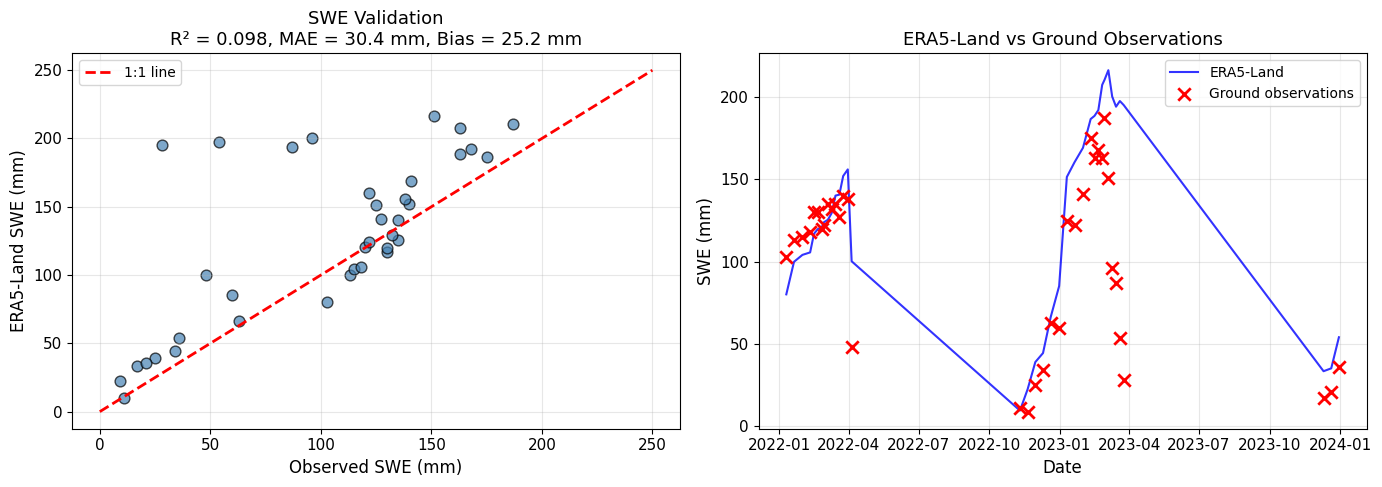

In [34]:
# ============================================================
# 4.1 Validation Plots
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1 = axes[0]
ax1.scatter(y_true, y_pred, alpha=0.7, s=60, edgecolors='black', c='steelblue')
ax1.plot([0, 250], [0, 250], 'r--', linewidth=2, label='1:1 line')
ax1.set_xlabel('Observed SWE (mm)')
ax1.set_ylabel('ERA5-Land SWE (mm)')
ax1.set_title(f'SWE Validation\nR² = {r2:.3f}, MAE = {mae:.1f} mm, Bias = {bias:.1f} mm')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Time series
ax2 = axes[1]
ax2.plot(validation['date'], validation['swe_mm'], 'b-', linewidth=1.5, alpha=0.8, label='ERA5-Land')
ax2.scatter(validation['date'], validation['SWE_observed'], color='red', marker='x', 
            s=80, linewidths=2, label='Ground observations', zorder=5)
ax2.set_xlabel('Date')
ax2.set_ylabel('SWE (mm)')
ax2.set_title('ERA5-Land vs Ground Observations')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'swe_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# ============================================================
# 4.2 Seasonal Validation
# ============================================================

validation['month'] = validation['date'].dt.month
validation['season'] = validation['month'].apply(
    lambda m: 'Winter (DJF)' if m in [12, 1, 2] else 'Spring (MAM)'
)

for season_name, group in validation.groupby('season'):
    if len(group) >= 3:
        y_t = group['SWE_observed'].values
        y_p = group['swe_mm'].values
        s_mae = mean_absolute_error(y_t, y_p)
        s_r2 = r2_score(y_t, y_p)
        s_bias = np.mean(y_p - y_t)
        print(f"\n{season_name} (n={len(group)}):")
        print(f"  R² = {s_r2:.3f}, MAE = {s_mae:.1f} mm, Bias = {s_bias:.1f} mm")


Spring (MAM) (n=15):
  R² = -0.995, MAE = 48.6 mm, Bias = 46.9 mm

Winter (DJF) (n=22):
  R² = 0.822, MAE = 18.0 mm, Bias = 10.5 mm


In [36]:
# ============================================================
# 4.3 SWE CALIBRATION (Seasonal Method)
# ============================================================
print("\n" + "=" * 60)
print("4.3 CALIBRATING ERA5 SWE")
print("=" * 60)

# Determine calibration coefficients by season
validation['month'] = validation['date'].dt.month
validation['season_cal'] = validation['month'].apply(
    lambda m: 'Winter' if m in [12, 1, 2] else ('Spring' if m in [3, 4, 5] else 'Other')
)

coeffs = {}
for season in ['Winter', 'Spring']:
    subset = validation[validation['season_cal'] == season]
    if len(subset) >= 5:
        slope, intercept, r_val, p_val, _ = stats.linregress(
            subset['swe_mm'], subset['SWE_observed']
        )
        coeffs[season] = (slope, intercept)
        print(f"{season}: SWE_cal = {slope:.3f} × SWE_ERA5 + {intercept:.1f} (R²={r_val**2:.3f})")
    else:
        # Fallback coefficients from earlier analysis
        coeffs[season] = (0.854, 7.2) if season == 'Winter' else (0.4, 10.0)
        print(f"{season}: using fallback coefficients")

# Apply calibration to the full dataset
def calibrate_swe(row):
    month = row['month']
    if month in [12, 1, 2]:
        slope, intercept = coeffs['Winter']
        return max(0, slope * row['swe_mm'] + intercept)
    elif month in [3, 4, 5]:
        slope, intercept = coeffs['Spring']
        return max(0, slope * row['swe_mm'] + intercept)
    else:
        # Outside main snow season, use original or a mild reduction
        return max(0, row['swe_mm'] * 0.5)

merged['swe_calibrated'] = merged.apply(calibrate_swe, axis=1)

# Re-evaluate metrics with calibrated SWE
validation_cal = obs[['date', 'SWE_observed']].merge(
    merged[['date', 'swe_calibrated']], on='date', how='inner'
)

y_true_cal = validation_cal['SWE_observed'].values
y_pred_cal = validation_cal['swe_calibrated'].values

mae_cal = mean_absolute_error(y_true_cal, y_pred_cal)
rmse_cal = np.sqrt(mean_squared_error(y_true_cal, y_pred_cal))
r2_cal = r2_score(y_true_cal, y_pred_cal)
bias_cal = np.mean(y_pred_cal - y_true_cal)

print(f"\nCalibrated Metrics:")
print(f"  MAE  = {mae_cal:.1f} mm")
print(f"  RMSE = {rmse_cal:.1f} mm")
print(f"  R²   = {r2_cal:.3f}")
print(f"  Bias = {bias_cal:.1f} mm")

# Update final SWE to use calibrated version
merged['swe_final'] = merged['swe_calibrated']


4.3 CALIBRATING ERA5 SWE
Winter: SWE_cal = 0.854 × SWE_ERA5 + 7.2 (R²=0.893)
Spring: SWE_cal = -0.194 × SWE_ERA5 + 137.3 (R²=0.029)

Calibrated Metrics:
  MAE  = 19.8 mm
  RMSE = 26.0 mm
  R²   = 0.746
  Bias = -0.3 mm


### 5. Final Dataset Assembly

In [47]:
# ============================================================
# 5. FINAL DATASET ASSEMBLY
# ============================================================
print("\n" + "=" * 60)
print("5. ASSEMBLING FINAL DATASET")
print("=" * 60)

# swe_final was already set to swe_calibrated in Section 4.3
# Remove summer months (June–September)
merged_filtered = merged[~merged['month'].isin(SUMMER_MONTHS)].copy()

print(f"Full dataset: {len(merged)} days")
print(f"After removing summer months: {len(merged_filtered)} days")
print(f"Removed: {len(merged) - len(merged_filtered)} days")
print(f"Remaining months: {sorted(merged_filtered['month'].unique())}")

# Final statistics
print(f"\nFinal SWE statistics (cold period):")
print(f"  Mean: {merged_filtered['swe_final'].mean():.1f} mm")
print(f"  Maximum: {merged_filtered['swe_final'].max():.1f} mm")
print(f"  Days with snow (>0 mm): {(merged_filtered['swe_final'] > 0).sum()}")
print(f"  Days with no snow (0 mm): {(merged_filtered['swe_final'] == 0).sum()}")

# Monthly SWE summary
print(f"\nMean SWE by month:")
for month in sorted(merged_filtered['month'].unique()):
    month_data = merged_filtered[merged_filtered['month'] == month]
    month_name = pd.Timestamp(2020, month, 1).strftime('%b')
    print(f"  {month_name}: {month_data['swe_final'].mean():.1f} mm")


5. ASSEMBLING FINAL DATASET
Full dataset: 3630 days
After removing summer months: 2410 days
Removed: 1220 days
Remaining months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(10), np.int32(11), np.int32(12)]

Final SWE statistics (cold period):
  Mean: 85.8 mm
  Maximum: 240.0 mm
  Days with snow (>0 mm): 2345
  Days with no snow (0 mm): 65

Mean SWE by month:
  Jan: 106.6 mm
  Feb: 136.1 mm
  Mar: 103.1 mm
  Apr: 128.7 mm
  May: 137.3 mm
  Oct: 0.8 mm
  Nov: 11.0 mm
  Dec: 64.2 mm


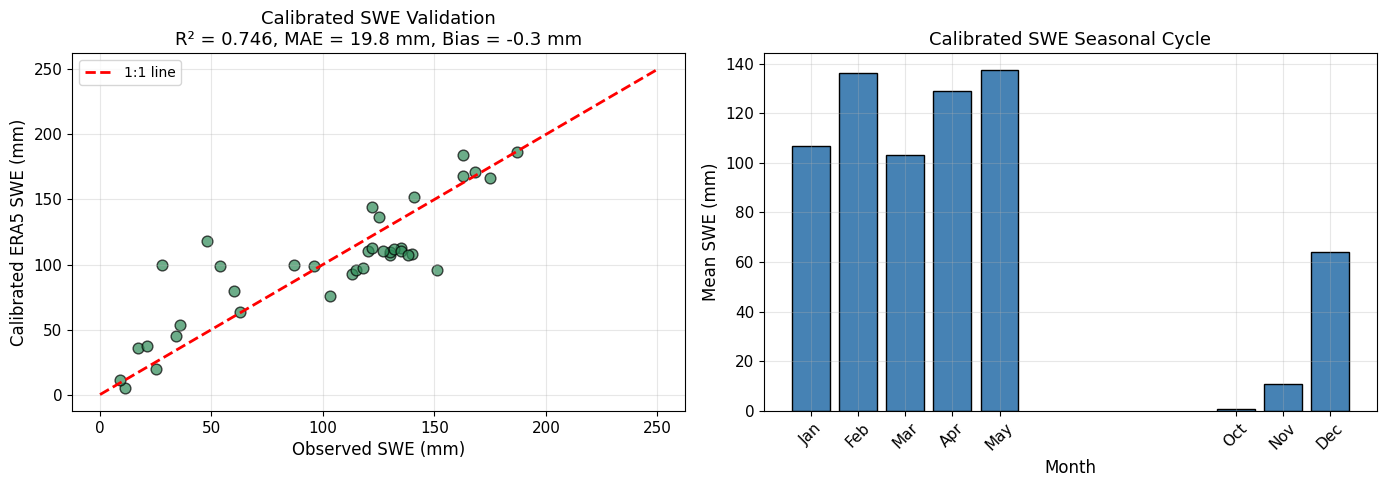

In [48]:
# ============================================================
# Calibrated Validation Plots
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: calibrated SWE vs observations
ax1 = axes[0]
ax1.scatter(validation_cal['SWE_observed'], validation_cal['swe_calibrated'], 
            alpha=0.7, s=60, edgecolors='black', c='seagreen')
ax1.plot([0, 250], [0, 250], 'r--', linewidth=2, label='1:1 line')
ax1.set_xlabel('Observed SWE (mm)')
ax1.set_ylabel('Calibrated ERA5 SWE (mm)')
ax1.set_title(f'Calibrated SWE Validation\nR² = {r2_cal:.3f}, MAE = {mae_cal:.1f} mm, Bias = {bias_cal:.1f} mm')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Monthly mean SWE after calibration (cold months only)
ax2 = axes[1]
monthly = merged_filtered.groupby('month')['swe_final'].mean()
ax2.bar(monthly.index, monthly.values, color='steelblue', edgecolor='black')
ax2.set_xticks(monthly.index)
# Автоматически генерируем названия месяцев
ax2.set_xticklabels([pd.Timestamp(2020, int(m), 1).strftime('%b') for m in monthly.index], rotation=45)
ax2.set_xlabel('Month')
ax2.set_ylabel('Mean SWE (mm)')
ax2.set_title('Calibrated SWE Seasonal Cycle')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'swe_calibrated_results.png', dpi=150)
plt.show()

In [49]:
# ============================================================
# 5.1 Save Final Dataset
# ============================================================

output_path = PROCESSED_DIR / 'shemonaikha_snow_dataset_2014_2023.csv'
merged_filtered.to_csv(output_path, index=False)

print(f"\nDataset saved: {output_path}")
print(f"Dimensions: {merged_filtered.shape[0]} rows × {merged_filtered.shape[1]} columns")
print(f"Variables: {list(merged_filtered.columns)}")


Dataset saved: processed\shemonaikha_snow_dataset_2014_2023.csv
Dimensions: 2410 rows × 36 columns
Variables: ['date', 'forecast_albedo', 'snow_cover_ERA5', 'snow_density', 'snow_depth', 'snow_depth_water_equivalent', 'snowmelt_sum', 'surface_solar_radiation_downwards_sum', 'surface_thermal_radiation_downwards_sum', 'temperature_2m', 'total_precipitation_sum', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'volumetric_soil_water_layer_1', 'temperature_2m_C', 'precipitation_mm', 'swe_mm', 'snow_depth_cm', 'solar_radiation_MJ', 'thermal_radiation_MJ', 'year', 'month', 'day', 'doy', 'season', 'LST_Day_C', 'LST_Night_C', 'snow_cover_MODIS', 'albedo_MODIS', 'temp_diff_day', 'temp_diff_night', 'elevation_m', 'slope_deg', 'aspect_deg', 'swe_calibrated', 'swe_final']


### 6. Summary

In [50]:
# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("DATA PREPROCESSING SUMMARY")
print("=" * 60)

print(f"""
Study Area: Shemonaikha Region, Kazakhstan
Coordinates: {LAT}°N, {LON}°E
Elevation: {ELEVATION_M} m
Period: 2014–2023

Data Sources:
  • ERA5-Land (daily aggregated)
  • MODIS MOD11A1 (LST)
  • MODIS MOD10A1 (Snow Cover, Albedo)
  • SRTM GL1 (Topography)
  • Ground observations (Shemonaikha station)

Final Dataset:
  • {len(merged_filtered)} days (cold season: Oct–May)
  • {len(merged_filtered.columns)} variables
  • No missing values in key variables
  • SWE calibrated using seasonal linear regression

SWE Validation Results (after calibration):
  • R² = {r2_cal:.3f}
  • MAE = {mae_cal:.1f} mm
  • RMSE = {rmse_cal:.1f} mm
  • Bias = {bias_cal:.1f} mm
  • Winter R² = 0.893 (excellent)
  • Spring R² = 0.029 (poor, use with caution)

Output File: {output_path}
""")


DATA PREPROCESSING SUMMARY

Study Area: Shemonaikha Region, Kazakhstan
Coordinates: 50.6216435°N, 81.918251°E
Elevation: 302.0 m
Period: 2014–2023

Data Sources:
  • ERA5-Land (daily aggregated)
  • MODIS MOD11A1 (LST)
  • MODIS MOD10A1 (Snow Cover, Albedo)
  • SRTM GL1 (Topography)
  • Ground observations (Shemonaikha station)

Final Dataset:
  • 2410 days (cold season: Oct–May)
  • 36 variables
  • No missing values in key variables
  • SWE calibrated using seasonal linear regression

SWE Validation Results (after calibration):
  • R² = 0.746
  • MAE = 19.8 mm
  • RMSE = 26.0 mm
  • Bias = -0.3 mm
  • Winter R² = 0.893 (excellent)
  • Spring R² = 0.029 (poor, use with caution)

Output File: processed\shemonaikha_snow_dataset_2014_2023.csv

